**This notebook ingests and processes locally stored LiDAR DEM data (114 tiles to cover AOI) from USGS National Map Data Delivery** https://apps.nationalmap.gov/downloader/ 

LiDAR DEM processing workflow also included redownloading corrupted files.

This notebook was ran in local_project_folder before copying to github repo.

**Part 0: Imports and filenames**

In [18]:
# Import libraries

import rasterio as rio
import rioxarray as rxr
import matplotlib.pyplot as plt

from pathlib import Path
import os

import json
import glob
from shapely.geometry import box
from rasterio.merge import merge
from rasterio.mask import mask
from rasterio.plot import show

**Process LiDAR DEM data**

In [7]:
# define dem directory

dem_dir = f'{Path.home()}/gda_course_2026v/projects/local_project_folder/raw_data_for_flooding/dem_data'

In [20]:
!ls $dem_dir

USGS_1M_10_x39y525_WA_Olympic_Peninsula_Lidar_2017_B17.tif
USGS_1M_10_x39y527_WA_Olympic_Peninsula_Lidar_2017_B17.tif
USGS_1M_10_x40y523_WA_Olympic_Peninsula_Lidar_2017_B17.tif
USGS_1M_10_x40y524_WA_Olympic_Peninsula_Lidar_2017_B17.tif
USGS_1M_10_x40y525_WA_Olympic_Peninsula_Lidar_2017_B17.tif
USGS_1M_10_x40y527_WA_Olympic_Peninsula_Lidar_2017_B17.tif
USGS_1M_10_x41y521_WA_Olympic_Peninsula_Lidar_2017_B17.tif
USGS_1M_10_x41y522_WA_Olympic_Peninsula_Lidar_2017_B17.tif
USGS_1M_10_x41y523_WA_Olympic_Peninsula_Lidar_2017_B17.tif
USGS_1M_10_x41y524_WA_Olympic_Peninsula_Lidar_2017_B17.tif
USGS_1M_10_x41y525_WA_Olympic_Peninsula_Lidar_2017_B17.tif
USGS_1M_10_x42y521_WA_Olympic_Peninsula_Lidar_2017_B17.tif
USGS_1M_10_x42y522_WA_Olympic_Peninsula_Lidar_2017_B17.tif
USGS_1M_10_x42y526_WA_Olympic_Peninsula_Lidar_2017_B17.tif
USGS_1M_10_x42y527_WA_Olympic_Peninsula_Lidar_2017_B17.tif
USGS_1M_10_x43y520_WA_Olympic_Peninsula_Lidar_2017_B17.tif
USGS_1M_10_x43y521_WA_Olympic_Peninsula_Lidar_2017_B17.t

In [8]:
# Define list of tif files using glob and tif wildcard to find/extract

tif_list = Path(dem_dir).glob('*tif')

In [81]:
# Loop through tif files in list and print metadata
# Code in this cell adapted from 
# https://towardsdatascience.com/usgs-dem-files-how-to-load-merge-and-crop-with-python-95cac546db91/

for tif in tif_list:
    with rio.open(tif) as src:
        # arr = src.read(1) too time-consuming
        print(f"\nDEM File: {tif}")
        print(f"Array Shape: {src.shape}")
        print(f"CRS: {src.crs}")
        print(f"NoData Value: {src.nodata}")


DEM File: /home/opana/gda_course_2026v/projects/local_project_folder/raw_data_for_flooding/dem_data/USGS_1m_x45y527_WA_Olympic_Peninsula_C1_2017.tif
Array Shape: (10012, 10012)
CRS: EPSG:26910
NoData Value: -3.4028230607370965e+38

DEM File: /home/opana/gda_course_2026v/projects/local_project_folder/raw_data_for_flooding/dem_data/USGS_1m_x48y523_WA_Olympic_Peninsula_C1_2017.tif
Array Shape: (10012, 10012)
CRS: EPSG:26910
NoData Value: -3.4028230607370965e+38

DEM File: /home/opana/gda_course_2026v/projects/local_project_folder/raw_data_for_flooding/dem_data/USGS_1m_x42y520_WA_Olympic_Peninsula_C2_2017.tif
Array Shape: (10012, 10012)
CRS: EPSG:26910
NoData Value: -3.4028230607370965e+38

DEM File: /home/opana/gda_course_2026v/projects/local_project_folder/raw_data_for_flooding/dem_data/USGS_1M_10_x40y523_WA_Olympic_Peninsula_Lidar_2017_B17.tif
Array Shape: (10012, 10012)
CRS: EPSG:26910
NoData Value: -999999.0

DEM File: /home/opana/gda_course_2026v/projects/local_project_folder/raw_da

In [9]:
# Changed directory to where dem .tif files are located to ensure
# gdal was pointed to the dem data

os.chdir("../raw_data_for_flooding/dem_data")

In [10]:
print(os.getcwd())

/home/opana/gda_course_2026v/projects/local_project_folder/raw_data_for_flooding/dem_data


In [84]:
# Use GDAL virtual raster to save time and disk space on mosaic
# Referenced https://www.perrygeo.com/lazy-raster-processing-with-gdal-vrts.html


!gdalbuildvrt ../../processed_data_for_flooding/lidar_merged.vrt /home/opana/gda_course_2026v/projects/local_project_folder/raw_data_for_flooding/dem_data/*.tif

0...10...20...30...40...50...60...70...80...90...100 - done.


**Resample VRT to 10 m resolution and save as lidar_merged_10m.vrt**

In [130]:
# Adapted code generated by Copilot AI (to resample to 10 m)

!gdalwarp \
  -tr 10 10 \
  -r bilinear \
  -multi \
  -of VRT \
  ../../processed_data_for_flooding/lidar_merged.vrt \
  ../../processed_data_for_flooding/lidar_merged_10m.vrt

Creating output file that is 10001P x 9001L.
Using internal nodata values (e.g. -999999) for image ../../processed_data_for_flooding/lidar_merged.vrt.
Copying nodata values from source ../../processed_data_for_flooding/lidar_merged.vrt to destination ../../processed_data_for_flooding/lidar_merged_10m.vrt.
Processing lidar_merged.vrt [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.


**Clip the 10 m VRT mosaic to Grays Harbor County and save as grays_harbor_dem_resampled.tif**

In [131]:
%%time
# Adapted code generated by AI Copilot to read VRT, 
# clip to Grays Harbor County geojson boundary created in 01_... 
# and write grays_harbor_dem.tif to processed_data_for_flooding folder

!gdalwarp \
  -cutline ../../processed_data_for_flooding/grays_harbor.geojson \
  -crop_to_cutline \
  -multi \
  -co TILED=YES \
  -co COMPRESS=LZW \
  -of GTiff \
  ../../processed_data_for_flooding/lidar_merged_10m.vrt \
  ../../processed_data_for_flooding/grays_harbor_dem_resampled.tif

Creating output file that is 9555P x 8327L.
Using internal nodata values (e.g. -999999) for image ../../processed_data_for_flooding/lidar_merged_10m.vrt.
Copying nodata values from source ../../processed_data_for_flooding/lidar_merged_10m.vrt to destination ../../processed_data_for_flooding/grays_harbor_dem_resampled.tif.
Processing lidar_merged_10m.vrt [1/1] : ]9;4;1;37]9;4;1;40]9;4;1;42]9;4;1;45]9;4;1;47]9;4;1;50]9;4;1;52]9;4;1;55]9;4;1;57]9;4;1;60]9;4;1;62]9;4;1;65]9;4;1;67]9;4;1;70]9;4;1;72]9;4;1;75]9;4;1;77]9;4;1;80]9;4;1;82]9;4;1;85]9;4;1;87]9;4;1;90]9;4;1;92]9;4;1;95]9;4;1;97]9;4;0;1000...10...20...30...40...50...60...70...80...90...100 - done in 00:00:14.                 
CPU times: user 225 ms, sys: 91.3 ms, total: 316 ms
Wall time: 14 s


In [11]:
# https://gda-wi26-jupyterbook.readthedocs.io/en/latest/modules/06_Raster2/06_demo.html
gh_dem_fn = "../../processed_data_for_flooding/grays_harbor_dem_resampled.tif"

In [12]:
gh_dem_da = rxr.open_rasterio(gh_dem_fn, masked=True).squeeze()
gh_dem_da

<xarray.DataArray (y: 8327, x: 9555)> Size: 318MB
[79564485 values with dtype=float32]
Coordinates:
  * y            (y) float64 67kB 5.265e+06 5.265e+06 ... 5.182e+06 5.182e+06
  * x            (x) float64 76kB 3.924e+05 3.924e+05 ... 4.879e+05 4.879e+05
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

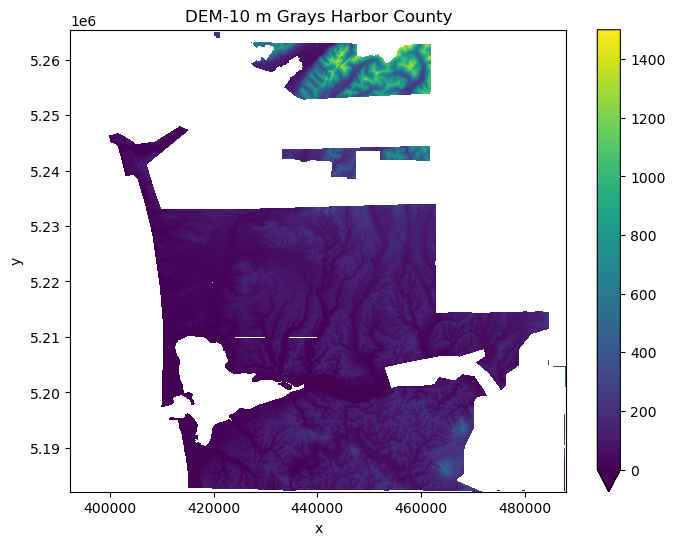

In [20]:
# Quick plot of DEM-10 m
f, axs = plt.subplots(figsize=(8,6))
gh_dem_da.plot.imshow(vmin=0,vmax=1500)
axs.set_title('DEM-10 m Grays Harbor County');

**Create a shaded relief map from resampled DEM**

Following cells include code adapted from

https://gda-wi26-jupyterbook.readthedocs.io/en/latest/modules/06_Raster2/06_demo.html

In [14]:
# https://gda-wi26-jupyterbook.readthedocs.io/en/latest/modules/06_Raster2/06_demo.html
hs_fn = os.path.splitext(gh_dem_fn)[0]+'_hs.tif'

In [22]:
%%time
if not os.path.exists(hs_fn):
    !gdaldem hillshade $gh_dem_fn $hs_fn

0...10...20...30...40...50...60...70...80...90...100 - done.
CPU times: user 58.9 ms, sys: 17.8 ms, total: 76.7 ms
Wall time: 2.06 s


**Use rasterio to load hillshade**

In [15]:
gh_hs_da = rxr.open_rasterio(hs_fn, masked=True).squeeze()
gh_hs_da

<xarray.DataArray (y: 8327, x: 9555)> Size: 318MB
[79564485 values with dtype=float32]
Coordinates:
  * y            (y) float64 67kB 5.265e+06 5.265e+06 ... 5.182e+06 5.182e+06
  * x            (x) float64 76kB 3.924e+05 3.924e+05 ... 4.879e+05 4.879e+05
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

**Quick hillshade plot**

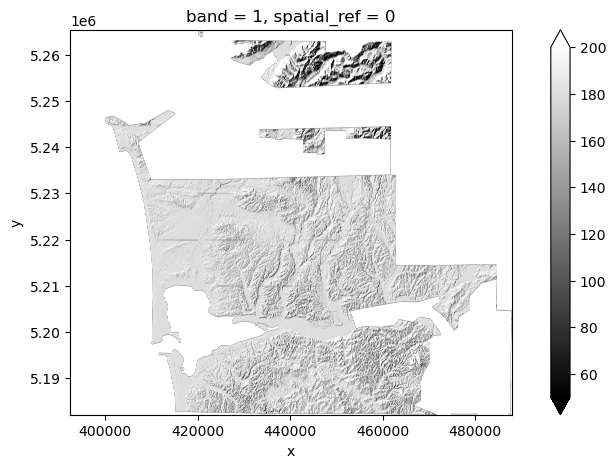

In [24]:
# https://gda-wi26-jupyterbook.readthedocs.io/en/latest/modules/06_Raster2/06_demo.html
f,ax=plt.subplots(figsize=(10, 5))
gh_hs_da.plot.imshow(ax=ax,vmin=50,vmax=200,cmap='gray', interpolation='bilinear')
ax.set_aspect('equal');

**Quick plot of DEM with hillshade overlay**

To avoid killing the kernel with overlay, plot downsampled versions

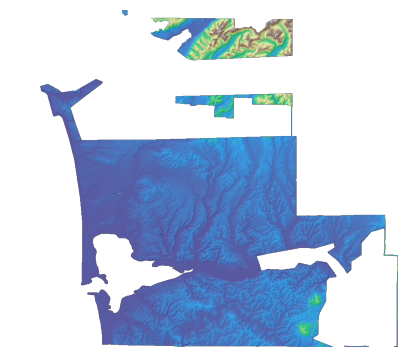

In [17]:
# Adapted AI code to plot large rasters
dem_small = gh_dem_da.coarsen(x=10, y=10, boundary="trim").mean()
hs_small = gh_hs_da.coarsen(x=10, y=10, boundary="trim").mean()

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(dem_small.values, cmap="terrain")
ax.imshow(hs_small.values, cmap="gray", alpha=0.3)
ax.set_axis_off()